# Chapter 18 - Entropy Features

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import random

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment
import statsmodels.api as sm

from utils.data_paths import IVE_TICKS
from utils.sampling_bars import dollar_bar
from utils.entropy import binary_encoding, quantile_encoding, sigma_encoding, plug_in_entropy_estimation, kontoyiannis_entropy_estimation

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

df = pd.read_parquet(IVE_TICKS)

dollar_bars = dollar_bar(df)

## 1. Form dollar bars on E-mini S&P 500 futures:

In [2]:
raw_returns = dollar_bars["price"].diff().dropna()

### a. Quantize the returns series using the binary method.

In [3]:
binary_encoded_returns = binary_encoding(raw_returns)

# count the number of each distinct values
pd.Series(binary_encoded_returns).value_counts()

0    683566
1    682152
Name: count, dtype: int64

### b. Quantize the returns series using the quantile encoding, using 10 letters.

In [4]:
quantile_encoded_returns = quantile_encoding(raw_returns, n_quantiles=10)

# count the number of each distinct values
pd.Series(quantile_encoded_returns).value_counts()

5    182248
6    144678
2    144635
3    144599
7    144460
9    144414
0    144369
8    144324
1    143873
4    106090
Name: count, dtype: int64

### c. Quantize the returns series using the sigma encoding, where $\sigma$ is the standard deviation of all bar returns.

In [5]:
sigma_encoded_returns = sigma_encoding(raw_returns, raw_returns.std())

# count the number of each distinct values
pd.Series(sigma_encoded_returns).value_counts()

553    1062633
554     245461
552      92285
555      20643
551      11108
        ...   
587          1
582          1
514          1
497          1
615          1
Name: count, Length: 107, dtype: int64

### d. Compute the entropy of the three encoded series, using the plug-in method.

In [6]:
binary_plugin_entropy = plug_in_entropy_estimation(binary_encoded_returns, 10)
quantile_plugin_entropy = plug_in_entropy_estimation(quantile_encoded_returns, 10)
sigma_plugin_entropy = plug_in_entropy_estimation(sigma_encoded_returns, 10)

print(f"Binary plugin entropy: {binary_plugin_entropy}")
print(f"Quantile plugin entropy: {quantile_plugin_entropy}")
print(f"Sigma plugin entropy: {sigma_plugin_entropy}")

Binary plugin entropy: 0.9999000220828593
Quantile plugin entropy: 2.0452939763890368
Sigma plugin entropy: 1.0922475432060341


It is normal that the quantile encoding obtains the highest entropy, as the uniform or close to uniform distribution of codes tends to increase entropy readings on average.

### e. Compute the entropy of the three encoded series, using Kontoyiannis’ method, with a window size of 100.

In [7]:
binary_konto_entropy = kontoyiannis_entropy_estimation(binary_encoded_returns, 100)
quantile_konto_entropy = kontoyiannis_entropy_estimation(quantile_encoded_returns, 100)
sigma_konto_entropy = kontoyiannis_entropy_estimation(sigma_encoded_returns, 100)

print(f"Binary konto entropy: {binary_konto_entropy['entropy']}")
print(f"Quantile konto entropy: {quantile_konto_entropy['entropy']}")
print(f"Sigma konto entropy: {sigma_konto_entropy['entropy']}")


Binary konto entropy: 0.8747620169411731
Quantile konto entropy: 2.465975794606167
Sigma konto entropy: 1.0546815112238161


## 2. Using the bars from exercise 1:

### a. Compute the returns series, $\{r_t\}$.

### b. Encode the series as follows: 0 if $r_tr_{t-1} < 0$, and 1 if $r_tr_{t-1} \geq 0$.

In [8]:
lagged_returns = raw_returns.shift(1)
multiplied_returns = raw_returns * lagged_returns
multiplied_returns = multiplied_returns.dropna()

binary_encoded_multiplied_returns = np.where(multiplied_returns < 0, 0, 1)

# count the number of each distinct values
pd.Series(binary_encoded_multiplied_returns).value_counts()

1    797194
0    646495
Name: count, dtype: int64

### c. Partition the series into 1000 non-overlapping subsets of equal size (you  may have to drop some observations at the beginning).

In [9]:
num_subsets = 1000
subset_size = len(binary_encoded_multiplied_returns) // num_subsets
num_to_drop = len(binary_encoded_multiplied_returns) - subset_size * num_subsets

# Drop observations from the beginning so the remaining sample splits exactly into 1000 blocks.
binary_encoded_multiplied_returns_trimmed = binary_encoded_multiplied_returns[num_to_drop:]
binary_encoded_multiplied_returns_subsets = binary_encoded_multiplied_returns_trimmed.reshape(
    num_subsets,
    subset_size,
)

print(f"Dropped observations: {num_to_drop}")
print(f"Subset array shape: {binary_encoded_multiplied_returns_subsets.shape}")


Dropped observations: 689
Subset array shape: (1000, 1443)


### d. Compute the entropy of each of the 1000 encoded subsets, using the plug-in method with word length 10.


In [10]:
plugin_word_length_subsets = 10
plugin_entropy_by_subset = pd.Series(
    [
        plug_in_entropy_estimation(subset, plugin_word_length_subsets)
        for subset in binary_encoded_multiplied_returns_subsets
    ],
    name="plug_in_entropy",
)

plugin_entropy_by_subset.describe()


count    1000.000000
mean        0.928913
std         0.017468
min         0.716816
25%         0.924598
50%         0.932968
75%         0.938100
max         0.948444
Name: plug_in_entropy, dtype: float64

### e. Compute the entropy of each of the 1000 encoded subsets, using the  Kontoyiannis method, with a window size of 100.

In [11]:
konto_entropy_by_subset = pd.Series(
    [kontoyiannis_entropy_estimation(subset, 100)["entropy"] for subset in binary_encoded_multiplied_returns_subsets],
    name="kontoyiannis_entropy",
)

konto_entropy_by_subset.describe()


count    1000.000000
mean        0.867423
std         0.015445
min         0.700100
25%         0.862335
50%         0.869508
75%         0.875796
max         0.892110
Name: kontoyiannis_entropy, dtype: float64

### f. Compute the correlation between results 2.d and 2.e.


In [12]:
subset_entropy_results = pd.concat(
    [plugin_entropy_by_subset, konto_entropy_by_subset],
    axis=1,
)
subset_entropy_correlation = subset_entropy_results.corr().loc[
    "plug_in_entropy",
    "kontoyiannis_entropy",
]

print(f"Correlation between plug-in and Kontoyiannis subset entropies: {subset_entropy_correlation}")
subset_entropy_results.describe()


Correlation between plug-in and Kontoyiannis subset entropies: 0.8794221918401205


,plug_in_entropy,kontoyiannis_entropy
count,1000.000000,1000.000000
mean,0.928913,0.867423
std,0.017468,0.015445
min,0.716816,0.700100
25%,0.924598,0.862335
50%,0.932968,0.869508
75%,0.938100,0.875796
max,0.948444,0.892110


## 3. Draw 1000 observations from a standard Normal distribution:

In [13]:
rng = np.random.default_rng(42)
observations = rng.normal(0, 1, 1000)


### a. What is the true entropy of this process?

The differential entropy of an IID $N(0,1)$ process is
$$h(X)=\frac{1}{2}\log(2\pi e\sigma^2).$$
The base of the logarithm determines the units. The helper functions in `utils.entropy` use `log2`, so the comparable continuous-entropy value is reported in bits. After quantile encoding into 8 equally populated labels, the true marginal discrete entropy of the encoded IID process is $\log_2(8)=3$ bits per observation.


In [14]:
true_entropy_normal_nats = 0.5 * np.log(2 * np.pi * np.e)
true_entropy_normal_bits = 0.5 * np.log2(2 * np.pi * np.e)
true_entropy_8_quantile_labels_bits = np.log2(8)

print(f"Differential entropy of N(0, 1): {true_entropy_normal_nats:.6f} nats")
print(f"Differential entropy of N(0, 1): {true_entropy_normal_bits:.6f} bits")
print(f"Entropy of the 8-quantile encoded IID process: {true_entropy_8_quantile_labels_bits:.6f} bits")


Differential entropy of N(0, 1): 1.418939 nats
Differential entropy of N(0, 1): 2.047096 bits
Entropy of the 8-quantile encoded IID process: 3.000000 bits


### b. Label the observations according to 8 quantiles.

In [15]:
quantile_encoded_observations = quantile_encoding(observations, n_quantiles=8)

print(pd.Series(quantile_encoded_observations).value_counts())

5    125
1    125
6    125
0    125
4    125
3    125
7    125
2    125
Name: count, dtype: int64


### c. Estimate the entropy using the plug-in method with word length 2.


In [16]:
plug_in_word_length_quantile = 2
quantile_plugin_entropy_normal = plug_in_entropy_estimation(
    quantile_encoded_observations,
    plug_in_word_length_quantile,
)
print(f"Entropy of the Normal labels estimated by plug-in method: {quantile_plugin_entropy_normal}")


Entropy of the Normal labels estimated by plug-in method: 2.9800460827448223


### d. Estimate the entropy using the Kontoyiannis method:

#### i. using a window size of 10.

In [17]:
quantile_konto_entropy_normal_10 = kontoyiannis_entropy_estimation(quantile_encoded_observations, 10)
print(f"Entropy of the Normal distribution estimated by Kontoyiannis method with window size 10: \n{quantile_konto_entropy_normal_10}")

Entropy of the Normal distribution estimated by Kontoyiannis method with window size 10: 
{'num': 981, 'sum': np.float64(2075.7742855696665), 'sub_seq': [], 'entropy': np.float64(2.1159778650047567), 'residual': np.float64(0.29467404499841443)}


#### ii. using a window size of 100.

In [18]:
quantile_konto_entropy_normal_100 = kontoyiannis_entropy_estimation(quantile_encoded_observations, 100)
print(f"Entropy of the Normal distribution estimated by Kontoyiannis method with window size 100: \n{quantile_konto_entropy_normal_100}")

Entropy of the Normal distribution estimated by Kontoyiannis method with window size 100: 
{'num': 801, 'sum': np.float64(1900.4754975601086), 'sub_seq': [], 'entropy': np.float64(2.372628586217364), 'residual': np.float64(0.20912380459421198)}


## 4. Using the draws from exercise 3, $\{x_t\}_{t = 1, \ldots 1000}$:

### a. Compute $y_t = \rho y_{t − 1} + x_t$, where $\rho = 0.5, y_0 = 0$.

In [19]:
rho = 0.5
num_obs = 1000

x_t = observations
kernel = rho ** np.arange(num_obs)
y_t = np.convolve(x_t, kernel, mode="full")[:num_obs]

print(y_t)

[ 3.04717080e-01 -8.87625566e-01  3.06638413e-01  1.09388392e+00
 -1.40409323e+00 -2.00422612e+00 -8.74272657e-01 -7.53378921e-01
 -3.93490618e-01 -1.04978924e+00  3.54503357e-01  9.55043614e-01
  5.43552504e-01  1.39901746e+00  1.16701807e+00 -2.75783427e-01
  2.30859071e-01 -8.43453066e-01  4.56723769e-01  1.78435973e-01
 -9.56443769e-02 -7.28751733e-01  8.58165472e-01  2.74553254e-01
 -2.91051195e-01 -4.97659148e-01  2.83479612e-01  5.07183870e-01
  6.66324547e-01  7.63983276e-01  2.52363924e+00  8.55404603e-01
 -8.45404275e-02 -8.56042942e-01  1.87957952e-01  1.22295127e+00
  4.97528177e-01 -5.91392389e-01 -1.12017741e+00  9.05040828e-02
  7.88506213e-01  9.37407375e-01 -1.96806020e-01  1.33758313e-01
  1.83564966e-01  3.10471080e-01  1.02666432e+00  7.36927708e-01
  1.04737742e+00  5.91267778e-01  5.84753288e-01  9.23664870e-01
 -9.95323385e-01 -8.17332909e-01 -8.79039109e-01 -1.07839740e+00
 -8.14340953e-01  1.08777083e+00 -3.21945698e-01  8.07305505e-01
 -1.27921702e+00 -9.74493

### b. Label $\{y_t\}$ the observations according to 8 quantiles.

In [20]:
quantile_encoded_y_t = quantile_encoding(y_t, n_quantiles=8)

print(pd.Series(quantile_encoded_y_t).value_counts())

4    125
1    125
6    125
0    125
2    125
3    125
5    125
7    125
Name: count, dtype: int64


### c. Estimate the entropy using the plug-in method with the same word length as exercise 3.


In [21]:
quantile_plugin_entropy_y_t = plug_in_entropy_estimation(
    quantile_encoded_y_t,
    plug_in_word_length_quantile,
)
print(f"Entropy of $y_t$ estimated by plug-in method: {quantile_plugin_entropy_y_t}")


Entropy of $y_t$ estimated by plug-in method: 2.878190207400486


### d. Estimate the entropy using the Kontoyiannis method

#### i. using a window size of 10.

In [22]:
quantile_konto_entropy_y_t_10 = kontoyiannis_entropy_estimation(quantile_encoded_y_t, 10)
print(f"Entropy of the $y_t$ estimated by Kontoyiannis method with window size 10: \n{quantile_konto_entropy_y_t_10}")

Entropy of the $y_t$ estimated by Kontoyiannis method with window size 10: 
{'num': 981, 'sum': np.float64(2005.3501419045504), 'sub_seq': [], 'entropy': np.float64(2.04418974709944), 'residual': np.float64(0.31860341763352007)}


#### ii. using a window size of 100.

In [23]:
quantile_konto_entropy_y_t_100 = kontoyiannis_entropy_estimation(quantile_encoded_y_t, 100)
print(f"Entropy of $y_t$ estimated by Kontoyiannis method with window size 100: \n{quantile_konto_entropy_y_t_100}")

Entropy of $y_t$ estimated by Kontoyiannis method with window size 100: 
{'num': 801, 'sum': np.float64(1806.8959204584812), 'sub_seq': [], 'entropy': np.float64(2.25580015038512), 'residual': np.float64(0.24806661653829332)}


## 5. Suppose a portfolio of 10 holdings with equal dollar allocations.

### a. The portion of the total risk contributed by the ith principal component is $\frac{1}{10}, i = 1, \ldots, 10$. What is the portfolio's entropy?

In [24]:
equal_risk_contrib = np.repeat(1 / 10, 10)
portfolio_entropy_5a = -np.sum(equal_risk_contrib * np.log(equal_risk_contrib))

print(f"Portfolio entropy: {portfolio_entropy_5a}")


Portfolio entropy: 2.3025850929940455


### b. The portion of the total risk contributed by the ith principal component is $\frac{11-i}{55}, i = 1, \ldots, 10$. What is the portfolio's entropy?


In [25]:
linear_risk_contrib = (11 - np.arange(1, 11)) / 55
portfolio_entropy_5b = -np.sum(linear_risk_contrib * np.log(linear_risk_contrib))

print(f"Risk contribution sum: {linear_risk_contrib.sum()}")
print(f"Portfolio entropy: {portfolio_entropy_5b}")


Risk contribution sum: 1.0
Portfolio entropy: 2.151281720651836


### c. The portion of the total risk contributed by the ith principal component is $\alpha \frac{1}{10} + (1 - \alpha)\frac{11-i}{55}, i = 1, \ldots, 10, \alpha \in [0,1]$. Plot the portfolio's entropy as a function of $\alpha$.


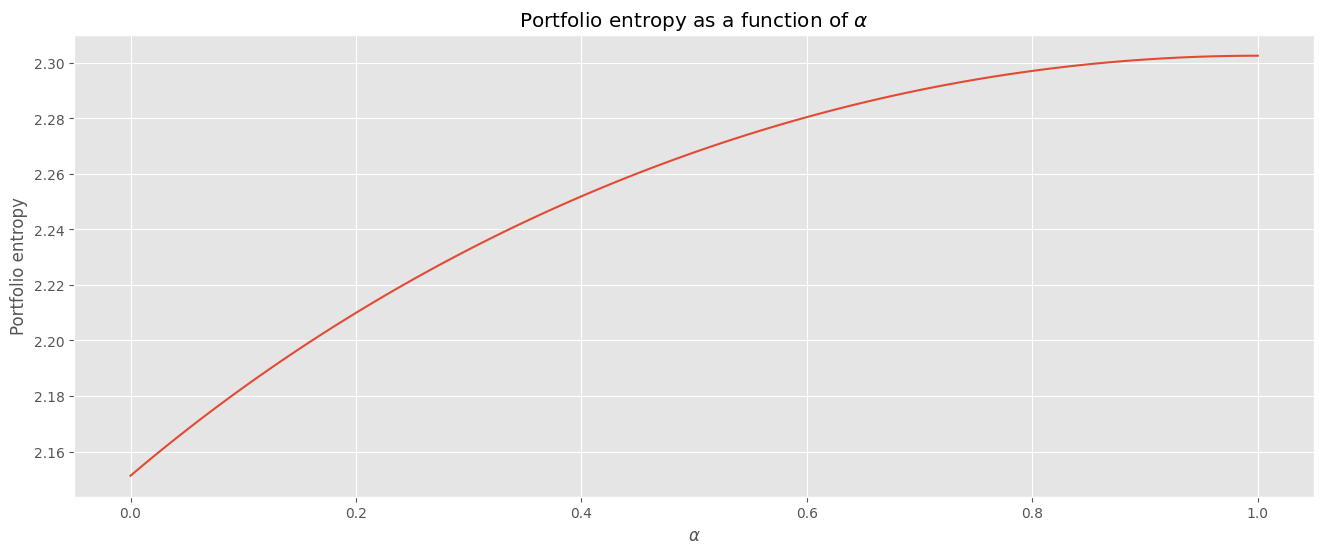

In [26]:
alphas = np.linspace(0, 1, 100)
equal_risk_contrib = np.repeat(1 / 10, 10)
linear_risk_contrib = (11 - np.arange(1, 11)) / 55

risk_contrib_by_alpha = (
    alphas[:, None] * equal_risk_contrib
    + (1 - alphas[:, None]) * linear_risk_contrib
)
entropies = -np.sum(risk_contrib_by_alpha * np.log(risk_contrib_by_alpha), axis=1)

plt.plot(alphas, entropies)
plt.xlabel(r"$\alpha$")
plt.ylabel("Portfolio entropy")
plt.title(r"Portfolio entropy as a function of $\alpha$")
plt.show()
